Found 657 images belonging to 3 classes.
Found 162 images belonging to 3 classes.
Classes: {'black_pepper_healthy': 0, 'black_pepper_leaf_blight': 1, 'black_pepper_yellow_mottle_virus': 2}
Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


D:\anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
21/21 ━━━━━━━━━━━━━━━━━━━━ 286s 13s/step - accuracy: 0.8432 - loss: 0.4464 - val_accuracy: 0.3395 - val_loss: 0.9204 - learning_rate: 3.0000e-05
Epoch 2/8
21/21 ━━━━━━━━━━━━━━━━━━━━ 266s 13s/step - accuracy: 0.9802 - loss: 0.1032 - val_accuracy: 0.8395 - val_loss: 0.6333 - learning_rate: 3.0000e-05
Epoch 3/8
21/21 ━━━━━━━━━━━━━━━━━━━━ 235s 11s/step - accuracy: 0.9893 - loss: 0.0464 - val_accuracy: 0.9444 - val_loss: 0.5036 - learning_rate: 3.0000e-05
Epoch 4/8
21/21 ━━━━━━━━━━━━━━━━━━━━ 285s 14s/step - accuracy: 0.9970 - loss: 0.0230 - val_accuracy: 0.9753 - val_loss: 0.4000 - learning_rate: 3.0000e-05
Epoch 5/8
21/21 ━━━━━━━━━━━━━━━━━━━━ 261s 12s/step - accuracy: 0.9985 - loss: 0.0160 - val_accuracy: 0.9753 - val_loss: 0.3327 - learning_rate: 3.0000e-05
Epoch 6/8
21/21 ━━━━━━━━━━━━━━━━━━━━ 261s 12s/step - accuracy: 0.9985 - loss: 0.0127 - val_accuracy: 0.9506 - val_loss: 0.3026 - learning_rate: 3.0000e-05
Epoch 7/8
21/21 ━━━━━━━━━━━━━━━━━━━━ 262s 13s/step - accuracy: 1.0000 

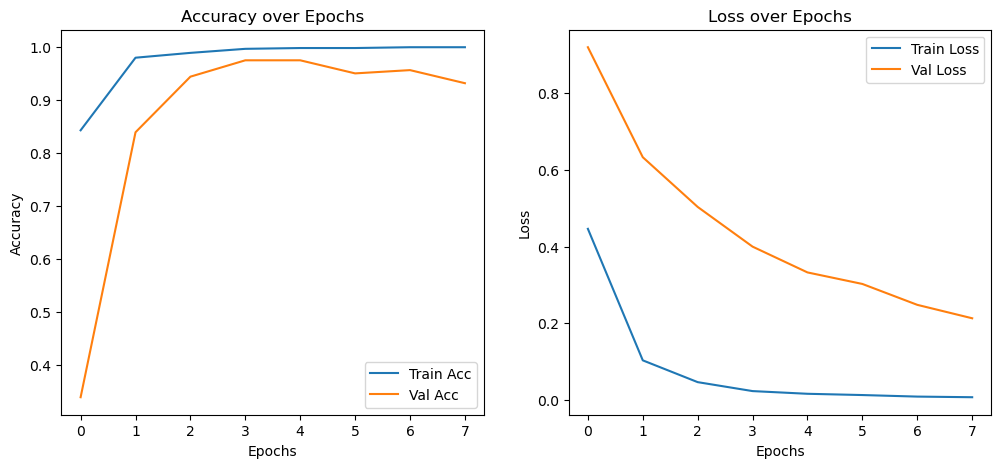

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)

# ======================================================
# CONFIG
# ======================================================
dataset_path = r"C:\Users\rsshr\OneDrive\Desktop\TARP PEPPER\archive"
img_size = (160, 160)
batch_size = 32

# ======================================================
# DATA
# ======================================================
datagen = ImageDataGenerator(
    validation_split=0.2,
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

train_gen = datagen.flow_from_directory(
    dataset_path, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='training'
)

val_gen = datagen.flow_from_directory(
    dataset_path, target_size=img_size, batch_size=batch_size,
    class_mode='categorical', subset='validation', shuffle=False
)

num_classes = len(train_gen.class_indices)
print("Classes:", train_gen.class_indices)

# ======================================================
# BUILD MODEL
# ======================================================
base_model = tf.keras.applications.VGG16(
    weights='imagenet', include_top=False, input_shape=(160, 160, 3)
)

for layer in base_model.layers[:10]:
    layer.trainable = False
for layer in base_model.layers[10:]:
    layer.trainable = True

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
model = tf.keras.models.Model(inputs=base_model.input, outputs=outputs)

# ======================================================
# CLASS WEIGHTS
# ======================================================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

# ======================================================
# COMPILE
# ======================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ======================================================
# CALLBACKS (NO MODEL CHECKPOINT)
# ======================================================
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
]

# ======================================================
# TRAIN (LIGHT FINE-TUNE)
# ======================================================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    class_weight=class_weights,
    callbacks=callbacks
)

# ======================================================
# EVALUATE
# ======================================================
y_pred_probs = model.predict(val_gen)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

acc = accuracy_score(y_true, y_pred_classes)
print("\nFinal Accuracy:", round(acc*100, 2), "%")

# ======================================================
# DETAILED PERFORMANCE METRICS
# ======================================================
prec_w = precision_score(y_true, y_pred_classes, average='weighted', zero_division=0)
rec_w = recall_score(y_true, y_pred_classes, average='weighted', zero_division=0)
f1_w = f1_score(y_true, y_pred_classes, average='weighted', zero_division=0)
prec_m = precision_score(y_true, y_pred_classes, average='macro', zero_division=0)
rec_m = recall_score(y_true, y_pred_classes, average='macro', zero_division=0)
f1_m = f1_score(y_true, y_pred_classes, average='macro', zero_division=0)

cm = confusion_matrix(y_true, y_pred_classes)
specificity_per_class = []
for i in range(len(cm)):
    tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
    fp = np.sum(cm[:, i]) - cm[i, i]
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity_per_class.append(specificity)
specificity = np.mean(specificity_per_class)

metrics_summary = {
    "Accuracy": acc,
    "Precision (Weighted)": prec_w,
    "Recall (Weighted)": rec_w,
    "F1-Score (Weighted)": f1_w,
    "Precision (Macro)": prec_m,
    "Recall (Macro)": rec_m,
    "F1-Score (Macro)": f1_m,
    "Specificity": specificity
}

print("\n================ Performance Metrics ================\n")
for k, v in metrics_summary.items():
    print(f"{k:25s}: {v:.4f}")

print("\nClassification Report:\n", classification_report(
    y_true, y_pred_classes, target_names=list(val_gen.class_indices.keys())))
print("\nConfusion Matrix:\n", cm)

# ======================================================
# PLOT ACCURACY & LOSS
# ======================================================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()
